### Group L : Taïs Thomas, Marouchka Heck, Marie-Caroline Bilocq

In [1]:
import matplotlib.pylab as plt 
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge

# 1. Cost functions

Lets focus on linear regression of the form 

$\mathbf{y} \approx f(\mathbf{X}) = \mathbf{X}\mathbf{w_1} + \mathbf{w_0}.$


#### 1.1 What are the rows of $\mathbf{X}$?

The rows of $X$ represent the different data points. Each row contains the information about one data point, with its values for the different features used to predict $y$.
If we have $N$ observations, the matrix $X$ has $N$ rows.

#### 1.2 What are the columns of $\mathbf{X}$?

The columns of $X$ represent the different features used to predict $y$. Each column contains the values of one feature for all the data points.
If we have $p$ features, the matrix $X$ has $p$ columns.

Often, we write the equation above as

$\mathbf{y} \approx \mathbf{\tilde{X}}\mathbf{w}$

#### 1.3 How does $\mathbf{\tilde{X}}$ look like in this case (i.e., how does the shape of the matrix change compared to $\mathbf{X}$)?



The matrix $\tilde{X}$ is a modified version of the original input matrix $X$ that allows us to include the intercept $w_0$ in the matrix multiplication. It is obtained by adding a column of ones to $X$, so that we can rewrite the linear regression equation as $y \approx \tilde{X}W$, where $W$ contains both the intercept and the weights associated with each feature.

For example, with 3 observations and 2 features:

$$
X =
\begin{pmatrix}
x_{11} & x_{12} \\
x_{21} & x_{22} \\
x_{31} & x_{32}
\end{pmatrix}
\quad \Rightarrow \quad
\tilde{X} =
\begin{pmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{pmatrix}
$$

The new weight vector $W$ contains both the intercept $w_0$ and the weights associated with each feature:

$$
W =
\begin{pmatrix}
w_0 \\
w_{11} \\
w_{12}
\end{pmatrix}
$$

Therefore, the equation can be written as:

$$
\begin{pmatrix}
y_1 \\
y_2 \\
y_3
\end{pmatrix}
\approx
\begin{pmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{pmatrix}
\begin{pmatrix}
w_0 \\
w_{11} \\
w_{12}
\end{pmatrix}
$$

The number of rows stays the same because we still have the same number of observations.
The number of columns increases by one because we added a column of ones for the intercept.

Therefore, the dimensions of the input matrix change from $N \times p$ for $X$ to $N \times (p+1)$ for $\tilde{X}$.

For machine learning, we need a cost function. Two common choices are the mean-squared error (MSE, $\mathcal{L}_2$), and the mean-absolute error (MAE, $\mathcal{L}_1$)

\begin{align}
    \mathcal{L}_2 &=& \frac{1}{N} \sum_{i=1}^N \left(y_i - f(x_i) \right)^2 \\
    \mathcal{L}_1 &=& \frac{1}{N} \sum_{i=1}^N \left|y_i - f(x_i) \right| 
\end{align}

#### 1.4 In the Jupyter notebook, write a Python function that computes these two cost functions given an error term $\boldsymbol{\epsilon} = \mathbf{y} - \mathbf{\tilde{X}}\mathbf{w}$

In [30]:
def mean_squared_error(error_vector):
    mean_squared_error = np.mean(error_vector**2)
    return mean_squared_error

In [31]:
mean_squared_error(np.array([0, 0, 0]))  # Expected to return 0 

0.0

In [32]:
mean_squared_error(np.array([1, 1, 1]))  # Expected to return 1

1.0

In [33]:
def mean_absolute_error(error_vector):
    mean_absolute_error = np.mean(np.abs(error_vector))
    return mean_absolute_error

In [34]:
mean_absolute_error(np.array([0, 0, 0]))  # Expected to return 0

0.0

In [35]:
mean_absolute_error(np.array([1, 1, 1]))  # Expected to return 1

1.0

Your code should run as follows

```python
mean_squared_error(np.array([0,0,0]))
> returns 0
```

```python
mean_squared_error(np.array([1,1,1]))
> returns 1
```

#### 1.5 What is the shape of these cost functions as a function of the error

In [71]:
x_axis = np.linspace(-10,10,100) # change as you wish for your plot
y_mae = [mean_absolute_error(x) for x in x_axis]
y_mse = [mean_squared_error(x) for x in x_axis]

Text(0, 0.5, 'cost function')

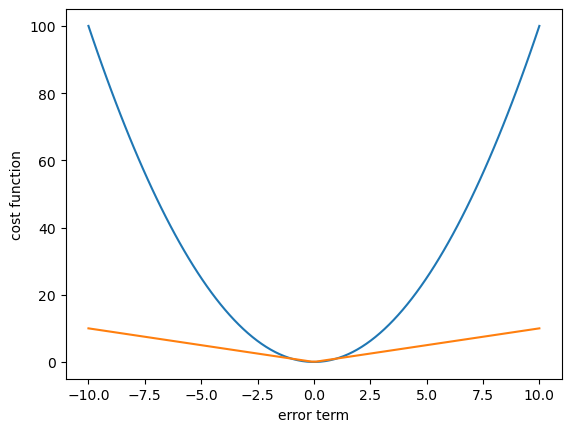

In [72]:
plt.plot(x_axis, y_mse, label='MSE')
plt.plot(x_axis, y_mae, label='MAE')
plt.xlabel('error term')
plt.ylabel('cost function')

By plotting the MSE and MAE as functions of the error, we can observe that:

- MSE: The curve has a U-shape (parabola) because the error is squared. As the absolute value of the error increases, the cost increases quadratically.

- MAE: The curve has a V-shape because it uses the absolute value of the error. As the absolute value of the error increases, the cost increases linearly.

Both curves are symmetric around zero, meaning that positive and negative errors of the same magnitude give the same cost. They both reach their minimum value of zero when the error is zero, corresponding to a perfect prediction.

To better understand the behavior of the cost functions, we also increased the error range from $[-10, 10]$ to $[-50, 50]$.

We can observe that the shapes of the curves remain the same, but the difference between their growth rates becomes more noticeable as the absolute error increases. For example, for an error of 50, the MSE reaches 2500 because the error is squared ($50^2 = 2500$), while the MAE only reaches 50 because it takes the absolute value of the error ($|50| = 50$).

This shows that the MSE increases much faster than the MAE for large errors, which explains why the MAE curve appears almost flat compared to the MSE curve when using a larger error range.


#### 1.6  Are both loss functions differentiable for all $\boldsymbol{\epsilon}$? What implications does this have for gradient based optimization like gradient descent?

- MSE: The MSE is differentiable for all values of $\varepsilon$ because it is a quadratic function. Its derivative is:

$$
\frac{d(MSE)}{d\varepsilon}=2\varepsilon
$$

- MAE: The MAE is not differentiable at $\varepsilon=0$ because its V-shaped curve has a sharp corner at this point. Its derivative is:

$$
\frac{d(MAE)}{d\varepsilon}=
\begin{cases}
-1 & \varepsilon < 0\\
1 & \varepsilon > 0
\end{cases}
$$

At $\varepsilon=0$, the derivative is undefined because the slope changes abruptly from -1 to +1.


- MSE: The MSE is differentiable for all values of $\varepsilon_i$ because it is a quadratic function. Its partial derivative with respect to each error $\varepsilon_i$ is:

$$
\frac{\partial MSE}{\partial \varepsilon_i} = \frac{2\varepsilon_i}{N}
$$

- **MAE:** The MAE is not differentiable at $\varepsilon_i = 0$ because its V-shaped curve has a sharp corner at this point. Its partial derivative is:

$$
\frac{\partial MAE}{\partial \varepsilon_i} =
\begin{cases}
-\frac{1}{N} & \varepsilon_i < 0\\
\frac{1}{N} & \varepsilon_i > 0
\end{cases}
$$

At $\varepsilon_i = 0$, the derivative is undefined because the slope changes abruptly from $-\frac{1}{N}$ to $\frac{1}{N}$.


- Implications for gradient descent:

Gradient descent uses the derivative of the cost function to determine how to update the model's weights and minimize the error.

For MSE, the derivative exists everywhere, so standard gradient descent can be applied directly.
For MAE, the derivative is undefined at zero, which can be problematic for standard gradient descent. However, methods such as subgradient descent can be used to handle this.


#### 1. Which loss function is more sensitive to outliers and why?

The MSE is more sensitive to outliers than the MAE because it squares the errors, giving much more importance to large errors. In comparison, the MAE is more robust to outliers because it uses the absolute values of the errors, so the cost increases linearly.

For example, consider a set of 5 prediction errors:

$$
\varepsilon = [1, 1, 2, 1, 10]
$$

Here, the first four errors are relatively small, while the last one ($\varepsilon_5 = 10$) represents an outlier.

The corresponding cost functions are:

$$
MSE = \frac{1^2 + 1^2 + 2^2 + 1^2 + 10^2}{5}
= \frac{107}{5} = 21.4
$$

$$
MAE = \frac{|1| + |1| + |2| + |1| + |10|}{5}
= \frac{15}{5} = 3
$$

If we replace the outlier with a normal error of 1, we obtain:

$$
MSE = \frac{1^2 + 1^2 + 2^2 + 1^2 + 1^2}{5}
= 1.6
$$

$$
MAE = \frac{|1| + |1| + |2| + |1| + |1|}{5}
= 1.2
$$

We can see that introducing the outlier increases the MSE from 1.6 to 21.4, while the MAE only increases from 1.2 to 3.

This confirms what we observed in Question 1.5. The MSE increases quadratically with the error, making it much more sensitive to outliers, whereas the MAE is more robust because it increases linearly.


# 2. Regularization

Assume that the columns of $\mathbf{X}$ are linearly independent.
As a refresher of linear algebra, recall when the linear system $\mathbf{X}\mathbf{w} = \mathbf{y}$ has

#### 2.1 One unique solution

__< Your answer >__

#### 2.2 No solution

__< Your answer >__

#### 2.3 An infinite number of solutions

__< Your answer >__

#### 2.4 Give a geometrical interpretation of the matrix Rank (10 bonus point if you use the Manim package)

__< Your answer >__

#### 2.5 In general, why can't we solve the linear equation using $\mathbf{y} = \tilde{\mathbf{X}}^{-1}\textbf{w}$? (1 point)

__< Your answer >__

#### 2.6 Differentiate above formula step by step and show what will we have?

__< Your answer >__

#### 2.7 if we want $\| y - \tilde{X} w \|_2^2$ to be minimum, what should the derivative be equal to?

__< Your answer >__

#### 2.8 What is the Hat matrix and what does its diagonal values correspond to?

__< Your answer >__

#### 2.9 What is Willson’s plot and how does it help in outlier detection?

__< Your answer >__

#### 2.10 What happens if some columns are linearly dependent? What is the connection to feature selection?

__< Your answer >__

#### 2.11 What will be the new cost function after adding the regularization term?

__< Your answer >__

#### 2.12 What will be the new 𝑤 when we differentiate the new cost function and set it to zero.

__< Your answer >__

#### 2.13 Prove that the part of Hat matrix where we want to take the inverse from is always reversible after we introduce the regularization term.

__< Your answer >__

#### 2.14  What is the shape of the parabola as a function of $a$?

In [73]:
def parabola(x, a = 1): 
    return a * x ** 2

In [74]:
x_axis_parabola = np.linspace(-10, 10, 100)

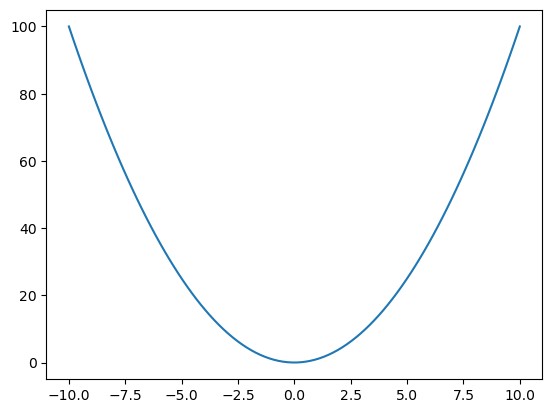

In [75]:
plt.plot(x_axis_parabola, parabola(x_axis_parabola))

__< Your answer >__

#### 2.15 Plot the approximation to the function for different order polynomials ($N \in \{1, 2, 16\}$) and with different regularization strength ($\lambda \in \{0, 10^{-3}, 10^{-2}, 1\}$). What do you observe 

In [76]:
def true_function(X):
    return np.cos(1.5 * np.pi * X)

In [77]:
X_test = np.linspace(0, 1, 100) # some grid for us on the x axis

In [78]:
n_samples = 10 # the number of points we will sample from true_function
degrees = [1, 2, 16] # the polynomial degrees we will test

X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.randn(n_samples) * 0.1 # add some scaled random noise

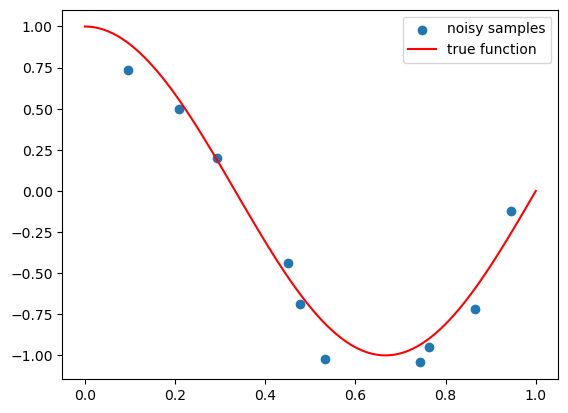

In [79]:
plt.scatter(X, y, label='noisy samples')
plt.plot(X_test, true_function(X_test), c='r', label='true function')
plt.legend()

The following code will fit a polynomial regression, you need to fill the degree

In [80]:
polynomial_features = PolynomialFeatures(degree=#FILLEME,
                                             include_bias=False)
linear_regression = LinearRegression()
pipeline = Pipeline([("polynomial_features", polynomial_features),
                     ("linear_regression", linear_regression)])
pipeline.fit(X[:, np.newaxis], y)

SyntaxError: invalid syntax (1035794253.py, line 2)

To plot the result, you can use the following code

In [ ]:
plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="model of degree ")
plt.scatter(X, y, label='noisy samples')
plt.plot(X_test, true_function(X_test), c='r', label='true function')
plt.legend()

Next, we can investigate the effect of the regularization parameter $\lambda$ (function parameter `alpha`), For this, you can use the following code 

In [ ]:
polynomial_features = PolynomialFeatures(degree=#fillme,
                                             include_bias=False)
ridge_regression = Ridge(alpha=#fillme)
pipeline_ridge = Pipeline([("polynomial_features", polynomial_features),
                     ("ridge_regression", ridge_regression)])
pipeline_ridge.fit(X[:, np.newaxis], y)


For plotting you can reuse the following code

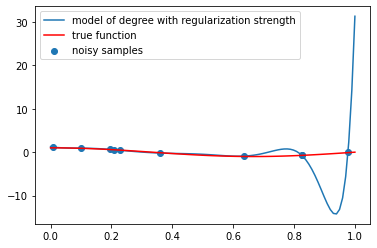

In [ ]:
plt.plot(X_test, pipeline_ridge.predict(X_test[:, np.newaxis]), label="model of degree with regularization strength")
plt.scatter(X, y, label='noisy samples')
plt.plot(X_test, true_function(X_test), c='r', label='true function')
plt.legend()

#### 2.16 What do you observe if you change the number of samples from the function?

__< Your answer >__

#### 2.17 Why do we need a test set in machine learning?

__< Your answer >__

#### 2.18 If we need to optimize hyperparameters, do we use the test set to select the best hyperparameters? (1 point)

__< Your answer >__